# ERP analysis using MNE



## Top-down view onto this notebook
To do: write here

## Exercise 2: Import, preprocess and inspect the data

Experimental setup: See notes on dataset

General EEG data information: See solutions file

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score # added cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import sklearn.metrics as metrics
import scipy as sp
import scipy.stats as stats
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

In [2]:
# Preparations

def load_and_preprocess_raw(header_file, filter_band=(0.5, 16)):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.filter(*filter_band, method="iir")
    raw.pick_types(eeg=True)
    return raw

def epoch_raw(raw, decimate=10):
    target_ids = list(range(111, 117))     # [111, 112, 113, 114, 115, 116]
    non_target_ids = list(range(101, 107)) # [101, 102, 103, 104, 105, 106]

    event_id = {f"Word_{i-110}/Target": i for i in target_ids}
    # {'Word_1/Target': 111, 'Word_2/Target': 112, 'Word_3/Target': 113, 'Word_4/Target': 114, 'Word_5/Target': 115, 'Word_6/Target': 116}
    
    event_id.update({f"Word_{i-100}/NonTarget": i for i in non_target_ids})
    # Same idea for non targets
    
    evs = mne.events_from_annotations(raw)[0]

    # print(evs.shape) # (548,3)
    # print(evs)
    # [[     0      0  99999]
    #  [  7538      0    201]
    #  [ 12077      0    101]
    #  ...
    #  [216368      0    101]
    #  [216621      0    103]
    #  [219940      0    255]]
    
    #epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
    #                   proj=False, tmax=1)

    # Added by me
    epoch = mne.Epochs(raw, events=evs, event_id=event_id, decim=decimate,
                       proj=False, tmax=1, baseline=None)
    return epoch

# Get the data path
data_dir = Path.cwd() / "data_a7" 
header_files = data_dir.glob("auditoryAphasia*.vhdr")

# Load the data, preprocess and slice it into epochs
epochs = list()
for f in header_files:
    raw_data = load_and_preprocess_raw(f)
    epochs.append(epoch_raw(raw_data))

# Overwrite epochs list to save memory
epochs = mne.concatenate_epochs(epochs) # len(epochs) = 3240

# Combine 6 epochs into a single iteration (6 stimuli together form a single iteration)
iterations = [epochs[i:i+6] for i in np.arange(0, epochs.events.shape[0],6)] # for loop goes from 0 to 3234 in steps of 6

# Assert that each iteration contains exactly 1 Target
assert all([len(iteration["Target"]) == 1 for iteration in iterations]), "Number of targets in single iterations is unequal to 1."

# 15 iterations form a single trial
trials = [iterations[i:i+15] for i in np.arange(0,len(iterations),15)]

In [3]:
# Printing the objects for visualisation
print("raw_data = ",raw_data)
print("\nepochs = \n",epochs)
print("\nlen(epochs) = ", len(epochs))

#print("\n iterations[0] = \n",iterations[0])
print("len(iterations) = ", len(iterations), " (each consists of 6 epochs)")
print("len(trials) = ", len(trials), " (each consists of 15 iterations)")

print("\nWe have 36 trials, each consists of 15 iterations (making 36 * 15 = 540 iterations in total)")
print("Each iteration consists of 6 events/words (making 540 * 6 = 3240 stimuli in total)")
print("This is in line with the total amount of epochs: 3240")

raw_data =  <RawBrainVision | auditoryAphasia_6D_Block1_Run7.eeg, 63 x 220240 (220.2 s), ~105.9 MiB, data loaded>

epochs = 
 <EpochsArray | 3240 events (all good), -0.2 – 1 s (baseline off), ~188.5 MiB, data loaded,
 'Word_1/Target': 90
 'Word_2/Target': 90
 'Word_3/Target': 90
 'Word_4/Target': 90
 'Word_5/Target': 90
 'Word_6/Target': 90
 'Word_1/NonTarget': 450
 'Word_2/NonTarget': 450
 'Word_3/NonTarget': 450
 'Word_4/NonTarget': 450
 and 2 more events ...>

len(epochs) =  3240
len(iterations) =  540  (each consists of 6 epochs)
len(trials) =  36  (each consists of 15 iterations)

We have 36 trials, each consists of 15 iterations (making 36 * 15 = 540 iterations in total)
Each iteration consists of 6 events/words (making 540 * 6 = 3240 stimuli in total)
This is in line with the total amount of epochs: 3240


In [ ]:
# Solution

# 2:
# Frequency range has been limited to [0,250]Hz. 
# Sampling rate is 1000 Hz.
# The intended temporal difference between 2 stimulus onsets is 250 ms. 
# This means that epochs will overlap a bit. This is not constant up to the ms because of delays in hardware and software, 
# drivers, audio cards, speakers, windows, etc.

# 3:
# -load_and_preprocess_raw() takes the header file and the desired frequency filter range. It separates the EEG from the non-EEG
#   channels, defines the channel layout (montage), applies the band-pass filter and returns the filtered EEG channels.
# -epoch_raw() takes the filtered EEG channels from load_and_preprocess_raw() and slices them up into epochs. The event IDs of 
#   these epochs will be replaced by their conditions: 'Word_i/Target' or 'Word_i/NonTarget' where i ∈ [1,6]. 
# -Event dictionaries like `event_id` are used when extracting epochs from continuous data. The `/` character in the dictionary 
#   keys allows pooling across conditions by requesting partial condition descriptors (i.e., requesting `Word_i` will select all 
#   epochs with that stimulus; requesting `Target` will select all epochs with targets.

# -Decimation of the sampling rate: we have a sampling rate of 1000Hz, as can be seen from the info of our epochs. This is a 
#   lot of data for our purposes.
# -We decimate with a factor 10, meaning every 10 samples, we only actually save 1 in our data. Thus our recorded sampling rate
#   of 1000 Hz becomes a realised sampling rate of 100Hz. Since we filter between 0.5 and 16Hz this is not an issue because 16Hz
#   is still below the Nyquist frequency

# 4:

scalp_times = (0.25, 0.30, 0.35, 0.45)
for i in np.arange(1,6):
    if i < 3:     # to not have a massive notebook
        epochs[f'Word_{i}']["Target"].average().plot_joint(title=f'target word {i}', times=scalp_times)
        epochs[f'Word_{i}']["NonTarget"].average().plot_joint(title=f'non-target word {i}', times=scalp_times)

plt.show()

# It becomes evident that target words have a larger negative response around 200ms, specifically around the sides and 
# the back of the head. 
# Also, the spread of the channels increases at 250ms for the target words. 

## Exercise 3: Calibration


### Comparing LDA vs sLDA vs BT-LDA on calibration data

#### Functions

In [135]:
# comparing LDA - BT-LDA - sLDA
# 19/04/2025_Exp_1

# data is in channel prime order
# evaulation method added from Jan's example_toeplitz_lda_simple.py

from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA

# See cell block in dump file for documentation on how this function works
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1))
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1]))
        idx_range = list(range(idx[0], idx[1]))
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2)
    return X

def compare_auc_single_trial_interval(start, stop):
    """
    compares LDA vs sLDA vs BT-LDA on calibration data
    calibration data is determined by selection trials [start - stop], e.g. [0-12]
    note that this is not robust! the interval matters
    """

    raw_calibration_trials = trials[start:stop] # change start & stop trial
    # online_trials = trials[12:] 
    clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
    calibration_trials_reshaped = np.array([
        [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
        for trial in calibration_trials
    ])

    # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

    # finish X and y to feed into classifier
    calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
    calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
    X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)

    # Evaluation of Jan's simple toeplitz example script
    # 19/04/2025_Exp_1a

    ### LDA
    clf_lda = make_pipeline(LDA(),)
    clf_lda.fit(X_train,y_train)

    y_df = clf_lda.decision_function(X_test)
    roc_auc_lda = roc_auc_score(y_test, y_df)
    y_pred = clf_lda.predict(X_test)
    bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

    print("LDA scores with channel prime data")
    print("roc_auc: ",roc_auc_lda)
    print("bal_acc_auc: ",bal_acc_auc_lda)

    ### sLDA
    clf_slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    clf_slda.fit(X_train,y_train)

    y_df = clf_slda.decision_function(X_test)
    roc_auc_slda = roc_auc_score(y_test, y_df)
    y_pred = clf_slda.predict(X_test)
    bal_acc_auc_slda = balanced_accuracy_score(y_test, y_pred)

    print("\nsLDA scores with channel prime data")
    print("roc_auc: ",roc_auc_slda)
    print("bal_acc_auc: ",bal_acc_auc_slda)

    ### BT-LDA
    # 19/04/2025: added from Jan's example_toeplitz_lda_simple.py:
    from toeplitzlda.classification import (
        EpochsVectorizer,
        ShrinkageLinearDiscriminantAnalysis,
        ToeplitzLDA,
    )

    clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    nch = 63
    # Straightforward use toeplitz lda
    clf_btlda = make_pipeline(
        # EpochsVectorizer(
        #     select_ival=feature_ival,
        # ),
        ToeplitzLDA(n_channels=nch),
    )
    clf_btlda.fit(X_train,y_train)

    y_df = clf_btlda.decision_function(X_test)
    roc_auc_btlda = roc_auc_score(y_test, y_df)
    y_pred = clf_btlda.predict(X_test)
    bal_acc_auc_btlda = balanced_accuracy_score(y_test, y_pred)

    print("\nBT LDA scores with channel prime data")
    print("roc_auc: ",roc_auc_btlda)
    print("bal_acc_auc: ",bal_acc_auc_btlda)


    # ------------------------------------------------------------------------------------------------------------
    #
    # comparing LDA - BT-LDA - sLDA using other evaluation method
    # 19/04/2025_Exp_1b

    # make sure data is in channel prime order by running the code block above
    # evaulation method from assignment 7, ex. 3 (calibration)
    # exact same auc scores as in Jan's evaluation method above

    # Evaluation of ex. 3 

    ### LDA

    lda = LDA()
    ldaclf = lda.fit(X_train, y_train)
    fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--') 
    plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the LDA classifier")
    plt.show()

    ### Shrinkage LDA

    slda = LDA(solver='lsqr',shrinkage = 'auto')
    slda.fit(X_train, y_train)
    print(slda.coef_.shape)

    fpr, tpr, thresholds = metrics.roc_curve(y_test,slda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the sLDA classifier")
    plt.show()

    ### BT-LDA

    # TO DO: try to set channel prime to False to let the class fix it vs manually fixing it (as done in assignment 6). See if it gives the same results 
    btlda = ToeplitzLDA(n_channels= 63) 
    btlda.fit(X_train, y_train) 

    fpr, tpr, thresholds = metrics.roc_curve(y_test,btlda.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary
    auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
    auc_fig.plot()
    plt.plot([0, 1],[0,1], '--')
    plt.legend(['ROC (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
    plt.title("AUC-ROC Curve of the BT-LDA classifier")
    plt.show()



#### Function call

LDA scores with channel prime data
roc_auc:  0.8197530864197531
bal_acc_auc:  0.7333333333333334

sLDA scores with channel prime data
roc_auc:  0.8117283950617283
bal_acc_auc:  0.6444444444444445


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



BT LDA scores with channel prime data
roc_auc:  0.8253086419753086
bal_acc_auc:  0.65


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


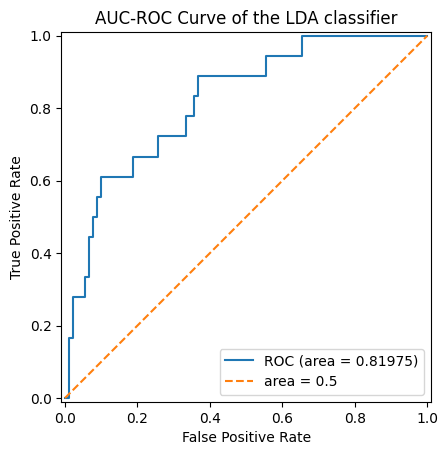

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1, 252)


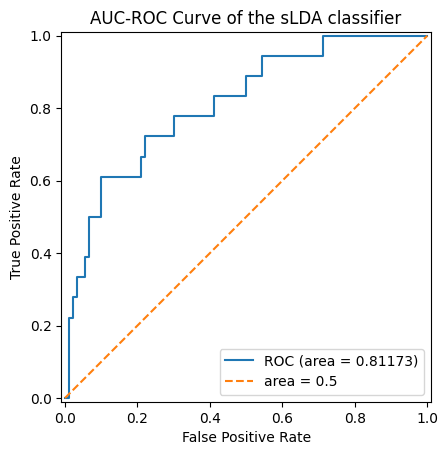

c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


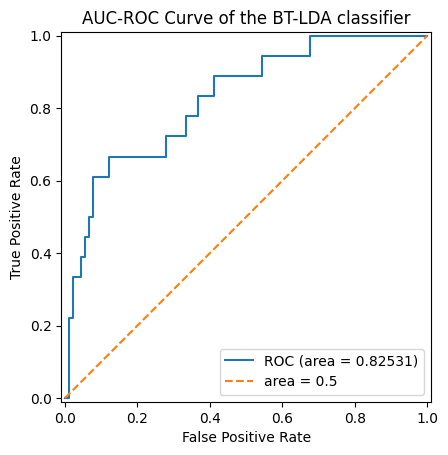

In [ ]:
# in 19/04/2025_Exp_1 trials [0-12] were used
# note that this evaluation is not robust, as the trial interval matters!
compare_auc_single_trial_interval(0,12)

### Average AUC on calibration using multiple trial samples

In [145]:
def compute_average_auc_calibration(classifier, trials, nch=63, tracker = False, 
                                    clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), size = 12):
    # Check if the classifier argument is valid
    if not isinstance(classifier, str):
        raise TypeError("The classifier is not of a valid type. It should be a string")
    elif not classifier in {"lda", "slda", "btlda"}:
        raise ValueError("The provided classifier is not recognized. Only the following are supported: {lda, slda, btlda")
    
    # Initialize classifier
    if classifier == "lda":
        lda = LDA(solver='lsqr')
    elif classifier == "slda":
        lda = LDA(solver='lsqr', shrinkage='auto')    
    elif classifier == "btlda":
        lda = make_pipeline(
        ToeplitzLDA(n_channels=nch),
        )    
    else:
        raise ValueError("Unrecognized classifier") 

    end = len(trials)-1 # 35
    scores = np.zeros(end-size)
    tracker = tracker

    for i in range(end-size):
        raw_calibration_trials = trials[i:i+size]
        clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
        calibration_trials = np.array([[get_jumping_means(iteration, clf_ival_boundaries) for iteration in trial] for trial in raw_calibration_trials])
        calibration_trials_reshaped = np.array([
            [epochs.transpose(0, 2, 1) for epochs in trial] # make channel prime
            for trial in calibration_trials
        ])

        # calibration_trials has shape (12, 15, 6, 63, 4) --> calibration_trials_reshaped has shape (12, 15, 6, 4, 63)

        # finish X and y to feed into classifier
        calibration_stimuli = np.reshape(calibration_trials_reshaped, (np.prod(calibration_trials_reshaped.shape[0:3]),-1)) # new shape: (1080, 252)
        calibration_labels = np.array([[[[1 if event > 107 else 0] for event in iteration.events[:,2]] for iteration in trial] for trial in raw_calibration_trials]).flatten() # shape (1080,), contains only 0's and 1's
        X_train, X_test, y_train, y_test = train_test_split(calibration_stimuli, calibration_labels, test_size=0.1, shuffle=False)


        # Fit classifier
        ldaclf = lda.fit(X_train, y_train)
        #fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

        y_df = ldaclf.decision_function(X_test)
        roc_auc_lda = roc_auc_score(y_test, y_df)
        y_pred = ldaclf.predict(X_test)
        bal_acc_auc_lda = balanced_accuracy_score(y_test, y_pred)

        if tracker:
            print ("Computing AUC for trials: {}-{} -> roc_auc = {}".format(i,i+size,roc_auc_lda))
            # print("bal_acc_auc: ",bal_acc_auc_lda)

        scores[i] = roc_auc_lda

    if tracker:
        print(scores)

    if tracker:
        print("Mean AUC of {}: {}".format(classifier,np.mean(scores)))

    return np.mean(scores)    


In [146]:
avg_auc_lda = compute_average_auc_calibration("lda",trials)
avg_auc_slda = compute_average_auc_calibration("slda",trials)
avg_auc_btlda = compute_average_auc_calibration("btlda",trials)


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

In [149]:
print("avg auc lda: ",avg_auc_lda)
print("avg auc slda: ",avg_auc_slda)
print("avg auc btlda: ",avg_auc_btlda)

avg auc lda:  0.7789049919484701
avg auc slda:  0.786580783682233
avg auc btlda:  0.8040794417606011


## Exercise 4: Simulated online experiment and dynamic stopping
Now it's time for the simulated online experiment! 🥳 In this exercise we will implement the early stopping method that uses a statistical test (Höhne's method).

In the online setting, we want to determine the target stimulus per trial. This is typically done at the end of the trial, however, in the case of dynamic stopping this prediction is made when we have sufficient evidence for one of the classes being the target class. To properly simulate an online experiment, you would have to treat each stimulus as if it had been just recorded. Normally, this means you would have to apply all the preprocessing steps (spectral filtering, downsampling,  etc.). We already did that for you while importing the data. So, all that is left for you to do in terms of preprocessing is extracting the features by applying the time interval averaging using the `get_jumping_means()` function (as shown in the code given below). 

#### Some information about the variables:
- `online_trial_targets` contains the target word id ($[1,2, ..,6]$) per trial. These should **only** be used to quantify the performance.
- `online_labels` contains whether the presented stimulus/word is a target (1) or a non-target (0). Note that the order of stimuli differs per iteration.
- `online_words` contains the word id ($[1,2, ..,6]$) per stimulus/word presentation. 

1. Inspect the code given below. In this code the classifier predicts the signed distance to the decision boundary, given a single presented stimulus/word. You will build on top of this code, so make sure you understand the three variables listed above.

1. **Condition A: no dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial, using the entire trial information. In other words, keep track of the **signed distances** to the decision hyperplane per word id throughout the entire trial to make a single prediction about the target word after all 15 iterations. Report your prediction accuracy. 
**NOTE**: The order in which words are presented differs per iteration in a trial. Also note that the classifier tried to learn a decision hyperplane such that targets have a positive signed distance to the hyperplane, and non-targets have a negative signed distance to the hyperplane.

1.  **Condition B: dynamic stopping applied.** Predict (using the provided classifier `clf`) the target words per trial while using a dynamic stopping procedure (Höhne's method). Perform a [(Welch's) t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test) (look for the approriate Scipy function) per iteration to see whether you can stop the trial early. Make sure to first gather at least a few iterations before you start checking whether you can stop the trial early. You can decide on the p-value and the minimum number of iterations you wish to use. 

1. Report the average accuracy and average number of iterations per trial when using the dynamic stopping procedure with this p-value. Also convert the average number of iterations per trial to the average duration of a trial in seconds (using the sampling frequency).
    
1. Visualise:
    * The trade-off between accuracy and the p-value threshold.
    * the trade-off between the average time (s) of a trial and the p-value threshold. 
    * The trade-off between accuracy and the average time (s) of a trial.

    You can visualise this by repeating 3.4 for a range of p-value threshold values. Make use of the p-value thresholds in the range of [0.001,0.5] with a sufficiently small step size to yield a somewhat smooth plot. 

    **Note:** For 3.5 you will loop over all trials in the online experiment using different values for the p_value threshold for dynamic stopping. This can take a few minutes when you have many different values for the threshold. For fun: you can have a look at using a progress bar for your loop, they are extremely easy and useful! An example is given in a code cell below.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


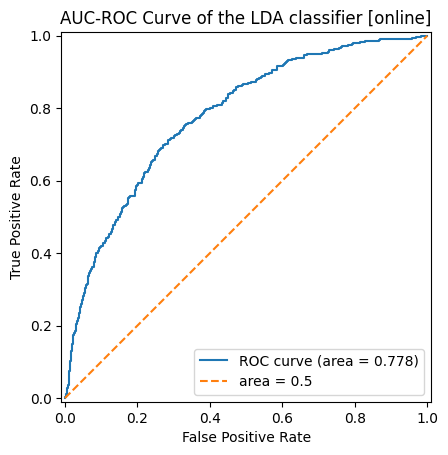

In [97]:
### This code is given and can be used in the subsequent exercises to build upon. unchanged

# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances = np.zeros(online_words.shape)

for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            signed_distances[t,i,s] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary

fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.3f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


# TO DO: change clf to ldclf

In [98]:
### [OPTIONAL]: Just for fun, you can use this function that plots the distributions of the signed distances of your candidate
###   target class vs the candidate non-target classes.
def plot_distribution_comparison(target_distances, non_target_distances): 
    signed_distances = [target_distances, non_target_distances]
    labels = ['predicted target', 'predicted non-targets']
    
    all_distances = np.concatenate((target_distances,non_target_distances),axis=None)
    x_min = np.min(all_distances)
    x_man = np.max(all_distances)
    x_axis = np.linspace(x_min, x_man)

    for i, distances in enumerate(signed_distances):
        # Fit and plot the distribution of the probabilities for the non-target words.
        mean, var  = sp.stats.distributions.norm.fit(distances)
        distri = stats.norm.pdf(x_axis,mean,np.sqrt(var))
        plt.plot(x_axis, distri, label=labels[i])

    plt.legend()
    plt.title("Distributions of the distances to the hyperplane")
    plt.xlabel("predicted distance")
    plt.ylabel("probability density function")
    plt.show()    

In [96]:
# Added (to be removed)
print(online_trial_targets)
print("\nonline_labels.shape: \n",online_labels.shape)
print("\n online_labels[0]: \n",online_labels[0])
print("\n online_words.shape: \n",online_words.shape)
print("\n online_words[0]: \n",online_words[0])

[2 6 4 1 5 3 4 5 3 6 2 1 4 6 3 5 1 2 4 3 6 5 2 1]

online_labels.shape: 
 (24, 15, 6)

 online_labels[0]: 
 [[0 0 0 1 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 0]]

 online_words.shape: 
 (24, 15, 6)

 online_words[0]: 
 [[6 3 4 2 5 1]
 [4 6 5 3 1 2]
 [4 6 3 5 1 2]
 [4 3 5 1 2 6]
 [3 2 4 1 5 6]
 [3 2 4 6 1 5]
 [4 3 6 1 5 2]
 [1 3 5 6 4 2]
 [6 5 2 1 3 4]
 [5 2 3 1 4 6]
 [2 3 6 1 5 4]
 [3 5 6 1 4 2]
 [3 6 4 1 5 2]
 [6 5 2 3 4 1]
 [3 5 2 4 6 1]]


### LDA vs sLDA vs BT-LDA

[0.1 0.2 0.3 0.4 0.5]


c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\Soz\anaconda3\envs\thesis\Lib\site-packages

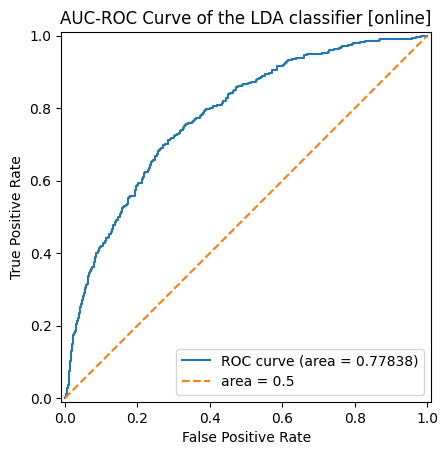

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


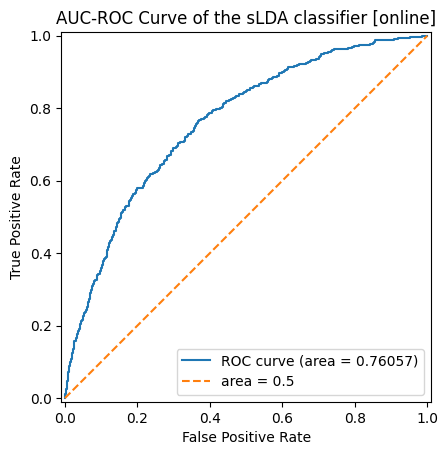

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


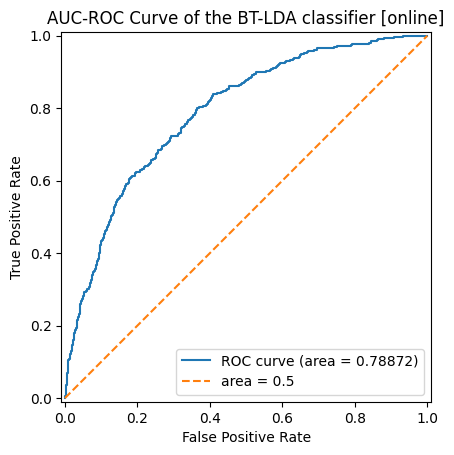

In [ ]:
# added 21/04/2025: copied from above + modifications
# modifications:
# - changed clf to ldaclf which is trained on channel prime data (do not apply clf on new, channel prime data as this has not been trained on this structure. i.e., be consistent with the data structure in both fitting and testing/applying)
# - added some comments 
# - changed input to decision_function to be channel-prime through .transpose(0,2,1)
# - added slda and btlda


# added from a nr of blocks above -----------------------------------------------------
    # Run 19/04/2025_Exp_1

# Evaluation of ex. 3 

### LDA

# lda = LDA()
# ldaclf = lda.fit(X_train, y_train)
ldaclf = make_pipeline(LDA(),)
ldaclf.fit(X_train,y_train)
fpr, tpr, thresholds = metrics.roc_curve(y_test,ldaclf.decision_function(X_test)) # Compute signed distance of stimulus to decision boundary

### Shrinkage LDA

# slda = LDA(solver='lsqr',shrinkage = 'auto')
# slda.fit(X_train, y_train)
slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
slda.fit(X_train,y_train)

### BT-LDA

# btlda = ToeplitzLDA(n_channels= 63) 
# btlda.fit(X_train, y_train) 

btlda = make_pipeline(
    ToeplitzLDA(n_channels=63),
)
btlda.fit(X_train,y_train)

# -------------------------------------------------------------------------------


# Extract relevant data, labels and the played words
online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
online_labels = np.array([[[[1 if event > 107 else 0][0] for event in iteration.events[:,2]] for iteration in trial] for trial in online_trials]) # The location of the target word in the sequence of 6 stimuli per iteration. Note that the order of stimuli differs per iteration.
online_words = np.array([[iteration.events[:,2]%10 for iteration in trial] for trial in online_trials]) # The word ID sequence that is presented per iteration. Note that the order of the presented words differs between iterations.

# 4.1: Predict target/non-target per stimulus.

signed_distances_lda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_slda = np.zeros(online_words.shape) # (24, 15, 6)
signed_distances_btlda = np.zeros(online_words.shape) # (24, 15, 6)
# online_trials has shape (24, 15, 6, 63, 121)
print(clf_ival_boundaries)

p = 0
for t, trial in enumerate(online_trials):
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
                        
            # changed to channel prime for bt-lda
            signed_distances_lda[t,i,s] = ldaclf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
            signed_distances_slda[t,i,s] = slda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1))[0]
            
            # Important note during debugging
            # btlda.decision_function returns an nd array of shape (). To access its value, you have to call .item() additionally, instead of taking the first element via [0] (as done for lda and slda)
            signed_distances_btlda[t,i,s] = btlda.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).transpose(0,2,1).flatten().reshape(1,-1)).item() 


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_lda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the LDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_slda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the sLDA classifier [online]")
plt.show()


fpr, tpr, thresholds = metrics.roc_curve(online_labels.flatten(),signed_distances_btlda.flatten()) 
auc_fig = metrics.RocCurveDisplay(fpr=fpr, tpr = tpr)
auc_fig.plot()
plt.plot([0, 1],[0,1], '--')
plt.legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr, tpr), 'area = 0.5'], loc="lower right")
plt.title("AUC-ROC Curve of the BT-LDA classifier [online]")
plt.show()



In [ ]:
### Answer here for 4.2 (Condition A, no dynamic stopping applied)

In [ ]:
### Answer here for 4.3 & 4.4 (Condition B, dynamic stopping applied + reporting the average accuracy and trial duration)

In [ ]:
### Example progress bar code, super useful and easy to use!
# You might have to run this once if you don't yet have the package:
#!pip install tqdm

import time
from tqdm.notebook import tqdm

array = np.arange(1,100,1)
for i, item in enumerate(tqdm(array)):
    time.sleep(0.02)

  0%|          | 0/99 [00:00<?, ?it/s]

In [ ]:
### Answer here for 4.5 (Visualisation of the trade-offs)

Trial 0 target prediction: word 2 with p-value of 0.000010
Trial 1 target prediction: word 6 with p-value of 0.000355
Trial 2 target prediction: word 4 with p-value of 0.000037
Trial 3 target prediction: word 1 with p-value of 0.086779
Trial 4 target prediction: word 5 with p-value of 0.000032
Trial 5 target prediction: word 3 with p-value of 0.000090
Trial 6 target prediction: word 4 with p-value of 0.000034
Trial 7 target prediction: word 5 with p-value of 0.000011
Trial 8 target prediction: word 3 with p-value of 0.000029
Trial 9 target prediction: word 6 with p-value of 0.019638
Trial 10 target prediction: word 2 with p-value of 0.004220
Trial 11 target prediction: word 1 with p-value of 0.000091
Trial 12 target prediction: word 5 with p-value of 0.007131
Trial 13 target prediction: word 6 with p-value of 0.001043
Trial 14 target prediction: word 3 with p-value of 0.000001
Trial 15 target prediction: word 5 with p-value of 0.046507
Trial 16 target prediction: word 1 with p-value of

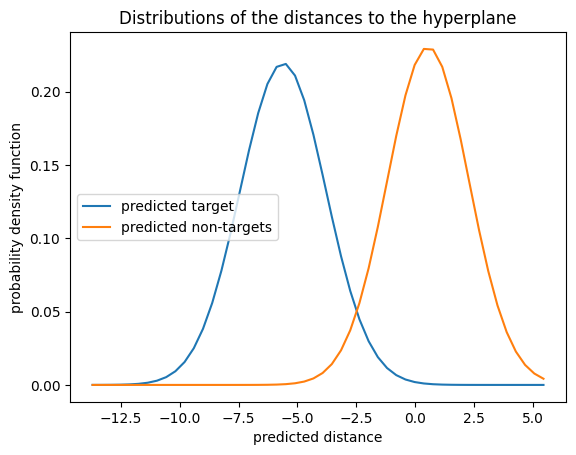

Accuracy: 0.96


In [ ]:
# Solution 4.2
trial_predictions = np.zeros(online_trial_targets.shape)
for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            
    means = np.mean(stim_distances, axis=0) # get the mean distance for each word
    best_guess = np.argmax(means)
    best_distances = stim_distances[:, best_guess].flatten()
    not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
    t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
    trial_predictions[t] = best_guess + 1
    print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p))    

plot_distribution_comparison(not_best_distances, best_distances)
print("Accuracy: %0.2f" % np.mean(trial_predictions == online_trial_targets))

In [ ]:
# Solution 4.3 & 4.4

trial_predictions = np.zeros(online_trial_targets.shape)
trial_times = np.zeros(online_trial_targets.shape)

p_threshold = 0.1

for t, trial in enumerate(online_trials):
    stim_distances = np.zeros(online_labels.shape[1:3])
    for i, iteration in enumerate(trial):
        for s, stimulus in enumerate(iteration):
            played_word = online_words[t,i,s] - 1 # to convert to indices
            stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
        if (i>5): # after 5/15 iteration
            means = np.mean(stim_distances, axis=0) # get the mean distance for each word
            best_guess = np.argmax(means)
            best_dist = stim_distances[:, best_guess].flatten()
            not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
            t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False) # equal_var = False gives us welch's t-test
            
            # Dynamic stopping
            if p_val<p_threshold or i==len(trial)-1:
                trial_times[t] = i
                trial_predictions[t] = best_guess + 1
                print("Trial %d was predicted with class %d after %d iterations with p-value of %0.6f" % (t, best_guess+1, i, p)) 
                break


_,_,n_stimuli,_, n_samples = np.array(online_trials).shape

# convert to seconds
print("Each iteration takes: %0.2f seconds to complete" % (n_stimuli*n_samples/epochs.info["sfreq"]))
trial_time_seconds = trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

print("The experiment took %0.2f seconds to complete" % np.sum(trial_time_seconds))
print("Each trial taking %0.2f seconds on average" % np.mean(trial_time_seconds))
print("The experiment achieved %0.2f %% accuracy" % (np.mean(trial_predictions == online_trial_targets)*100))


Trial 0 was predicted with class 2 after 6 iterations with p-value of 0.000001
Trial 1 was predicted with class 6 after 6 iterations with p-value of 0.000001
Trial 2 was predicted with class 4 after 6 iterations with p-value of 0.000001
Trial 3 was predicted with class 1 after 9 iterations with p-value of 0.000001
Trial 4 was predicted with class 5 after 6 iterations with p-value of 0.000001
Trial 5 was predicted with class 3 after 6 iterations with p-value of 0.000001
Trial 6 was predicted with class 4 after 6 iterations with p-value of 0.000001
Trial 7 was predicted with class 5 after 6 iterations with p-value of 0.000001
Trial 8 was predicted with class 3 after 6 iterations with p-value of 0.000001
Trial 9 was predicted with class 6 after 6 iterations with p-value of 0.000001
Trial 10 was predicted with class 2 after 6 iterations with p-value of 0.000001
Trial 11 was predicted with class 1 after 6 iterations with p-value of 0.000001
Trial 12 was predicted with class 5 after 8 iterat

In [ ]:
print(best_dist)
print(not_best_dist)

[-0.0614656  -2.58344812  0.10335954 -3.52346143  2.91485361 -9.03651175
  1.47490863  0.          0.          0.          0.          0.
  0.          0.          0.        ]
[ -3.74200694  -4.15245081  -4.71362542  -5.10232963  -2.57360692
  -8.83247766  -3.18231051  -9.63821338  -5.81336401   4.97147001
  -4.40846216  -5.21778471  -6.26923514  -5.89335557  -7.12675296
  -4.18804977  -5.17905841  -7.00607164  -7.84797104  -4.46278271
  -7.41385914  -3.16105154  -4.47897914  -9.63030666  -9.77689614
  -2.49623678 -11.91201474  -7.43603397  -3.61510024  -3.37624585
  -2.67936687 -11.92912714  -4.83109723  -0.53223581  -5.10945776
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.         

In [ ]:
# Solution 4.5

from tqdm.notebook import tqdm

n_trials,n_iterations,n_stimuli,_, n_samples = np.array(online_trials).shape
p_thresholds = np.arange(start=0.01,stop=0.5,step=0.01)
n_p_thresholds = p_thresholds.shape[0]

p_accuracy = np.zeros((n_p_thresholds))
p_trial_times = np.zeros((n_p_thresholds, n_trials))

for p, p_threshold in enumerate(p_thresholds):
    trial_predictions = np.zeros(n_trials)
    for t, trial in enumerate(online_trials):
        stim_distances = np.zeros(online_labels.shape[1:3])
        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):
                played_word = online_words[t,i,s] - 1 # to convert to indices
                stim_distances[i,played_word] = clf.decision_function(get_jumping_means(iteration[s],clf_ival_boundaries).flatten().reshape(1,-1))[0] # Compute signed distance of stimulus to decision boundary
            if (i>4):
                means = np.mean(stim_distances, axis=0) # get the mean distance for each word
                best_guess = np.argmax(means)
                best_dist = stim_distances[:, best_guess].flatten()
                not_best_dist = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
                t_score, p_val = stats.ttest_ind(best_dist, not_best_dist, equal_var = False)
                # Dynamic stopping
                if p_val<p_threshold or i==len(trial)-1:
                    p_trial_times[p][t] = i
                    trial_predictions[t] = best_guess + 1
                    break
    p_accuracy[p] = np.mean(trial_predictions == online_trial_targets)*100


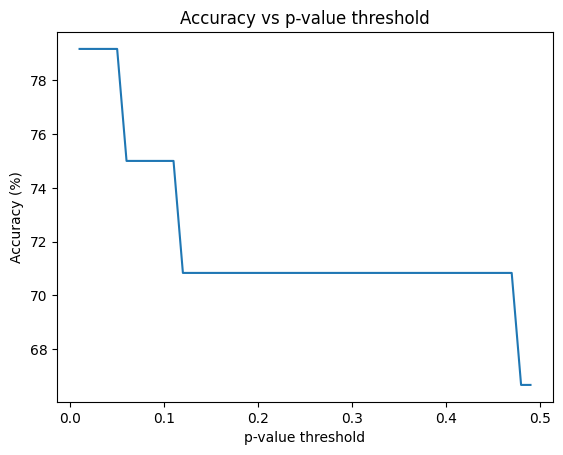

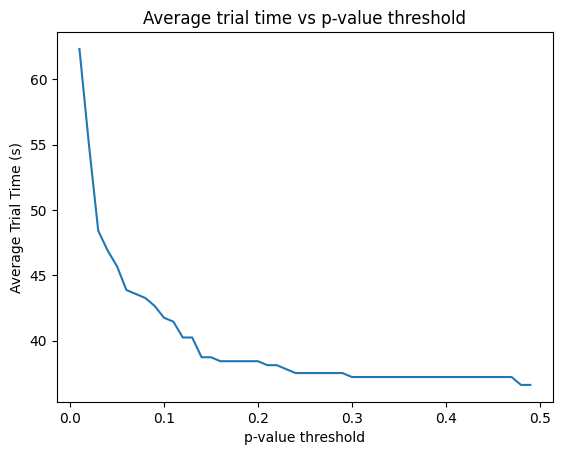

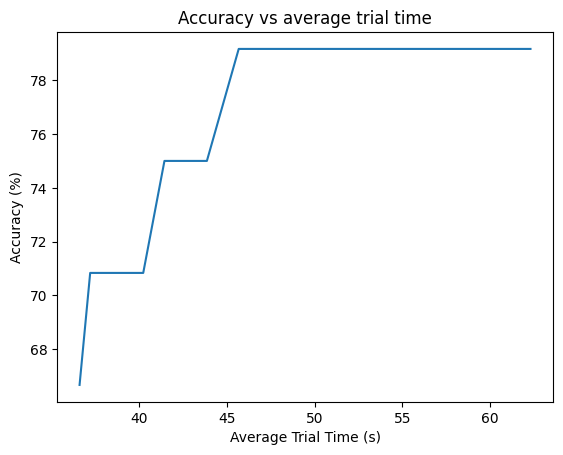

In [ ]:
# 4.5 continued
# convert trial times from iterations to seconds
trial_time_seconds = p_trial_times*(n_stimuli*n_samples/epochs.info["sfreq"]) 

plt.plot(p_thresholds, p_accuracy)
plt.title("Accuracy vs p-value threshold")
plt.xlabel('p-value threshold')
plt.ylabel('Accuracy (%)')
plt.show()

plt.plot(p_thresholds, np.mean(trial_time_seconds,axis=1))
plt.title("Average trial time vs p-value threshold")
plt.ylabel('Average Trial Time (s)')
plt.xlabel('p-value threshold')
plt.show()

plt.plot(np.mean(trial_time_seconds, axis = 1), p_accuracy)
plt.title("Accuracy vs average trial time")
plt.xlabel('Average Trial Time (s)')
plt.ylabel('Accuracy (%)')
plt.show()
